In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
from sklearn.neighbors import NearestNeighbors

from matplotlib.ticker import MaxNLocator
from pathlib import Path


project_root = Path.cwd()
project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [4]:
from src.clustering_baselines import KMeansTrainingLoop
from src.clustering_baselines import DBSCANEvaluation
from src.clustering_baselines import DBSCANMinSamplesEstimator
from src.clustering_baselines import DBSCANEpsEstimator

from src.plotting import PLOT_STYLES, plot_eps_metrics

# Load the engineered feature dataset

In [5]:
df_features = pd.read_csv(
    '../data/df_features.csv',
    dtype={'Invoice': 'string'},
    parse_dates=['invoice_datetime']
)
df_features

,Invoice,customer_id,invoice_datetime,invoice_total_amount,min_unit_price,max_unit_price,avg_unit_price,total_quantity,unique_item_count,is_cancelled,...,customer_dow_thu_rate,customer_dow_fri_rate,customer_dow_sat_rate,customer_dow_sun_rate,customer_tod_morning_rate,customer_tod_afternoon_rate,customer_tod_evening_rate,customer_tod_night_rate,customer_total_unique_products,customer_avg_days_between_orders
0,489434,13085.0,2009-12-01 07:45:00,505.30,1.25,6.95,4.081250,166,8,False,...,0.400000,0.300000,0.0,0.000000,0.400000,0.600000,0.000000,0.0,51,58.100000
1,489435,13085.0,2009-12-01 07:46:00,145.80,1.65,3.75,2.625000,60,4,False,...,0.400000,0.300000,0.0,0.000000,0.400000,0.600000,0.000000,0.0,51,58.100000
2,489436,13078.0,2009-12-01 09:06:00,630.33,1.25,8.50,3.730526,193,19,False,...,0.210526,0.147368,0.0,0.063158,0.294737,0.652632,0.052632,0.0,154,7.757895
3,489437,15362.0,2009-12-01 09:08:00,310.75,0.65,9.95,3.628261,145,23,False,...,0.000000,0.500000,0.0,0.000000,1.000000,0.000000,0.000000,0.0,38,145.000000
4,489438,18102.0,2009-12-01 09:24:00,2286.24,0.98,6.40,2.591176,826,17,False,...,0.261438,0.163399,0.0,0.019608,0.418301,0.470588,0.111111,0.0,384,5.089655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40500,C581484,16446.0,2011-12-09 09:27:00,-168469.60,2.08,2.08,2.080000,-80995,1,True,...,0.000000,0.500000,0.0,0.000000,0.750000,0.250000,0.000000,0.0,4,107.500000
40501,C581490,14397.0,2011-12-09 09:57:00,-32.53,0.83,1.95,1.390000,-23,2,True,...,0.173913,0.130435,0.0,0.130435,0.478261,0.478261,0.043478,0.0,18,9.217391
40502,C581499,15498.0,2011-12-09 10:28:00,-224.69,224.69,224.69,224.690000,-1,1,True,...,0.200000,0.309091,0.0,0.036364,0.400000,0.581818,0.018182,0.0,599,13.127273
40503,C581568,15311.0,2011-12-09 11:57:00,-54.75,10.95,10.95,10.950000,-5,1,True,...,0.140741,0.200000,0.0,0.044444,0.181481,0.814815,0.003704,0.0,870,2.743494


## Prepare the modeling matrix

Remove identifier and timestamp columns that should not drive clustering, then convert the binary `is_cancelled` flag to an integer representation.

Note on the influence of `is_cancelled` as a single binary feature: in downstream processing, the modeling matrix is standardized. Because cancellations are rare, `StandardScaler()` can create a relatively large z-score gap between 0 and 1 for this feature, which may increase its influence in Euclidean or cosine geometry. In this project, that influence is acceptable because cancellation behavior is intentionally treated as a meaningful anomaly signal.

In [6]:
X = df_features.drop(columns=["Invoice", "customer_id", "invoice_datetime"])
X["is_cancelled"] = X["is_cancelled"].astype(int)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40505 entries, 0 to 40504
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   invoice_total_amount               40505 non-null  float64
 1   min_unit_price                     40505 non-null  float64
 2   max_unit_price                     40505 non-null  float64
 3   avg_unit_price                     40505 non-null  float64
 4   total_quantity                     40505 non-null  int64  
 5   unique_item_count                  40505 non-null  int64  
 6   is_cancelled                       40505 non-null  int64  
 7   invoice_hour                       40505 non-null  int64  
 8   day_of_week                        40505 non-null  int64  
 9   invoice_month                      40505 non-null  int64  
 10  invoice_year                       40505 non-null  int64  
 11  customer_total_transactions        40505 non-null  int

## Standardize the feature matrix

Scale the features before PCA and distance-based clustering so variables measured on different ranges do not dominate the geometry of the space.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(40505, 44)

## Normalize the feature matrix

The sklearn.preprocessing.Normalizer class in scikit-learn rescales individual samples **(rows)** to have a unit norm. This is different from scaling features (columns) and is highly useful for text classification, clustering, or working with distance-based metrics

In [8]:
normalizer = Normalizer()
X_normalized = normalizer.fit_transform(X_scaled)

## Exploratory PCA

This PCA step is used as a quick diagnostic rather than a final modeling choice. The goal is to check whether a low-dimensional projection reveals any obvious structure before moving to clustering.

Note that the scatter plot below shows only the first two principal components, even though PCA is fitted to retain 95% of the total variance.

### References

* Jolliffe, I. T. (2002). Principal Component Analysis (2nd ed.). Springer

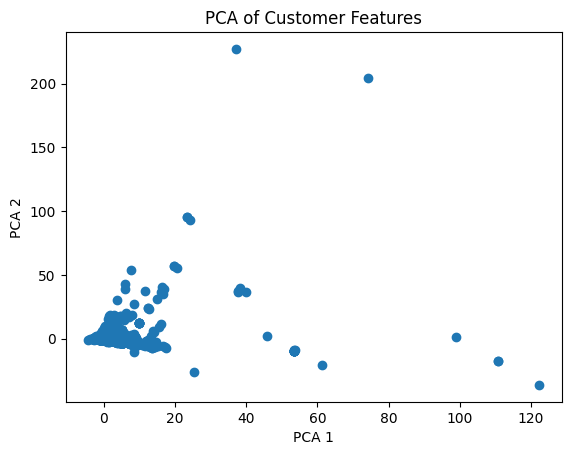

In [9]:
pca = PCA(n_components=0.95)  # Catch 95% of variance
pca_result = pca.fit_transform(X_scaled)

# plot PCA results - first 2 components
plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA of Customer Features")
plt.show()


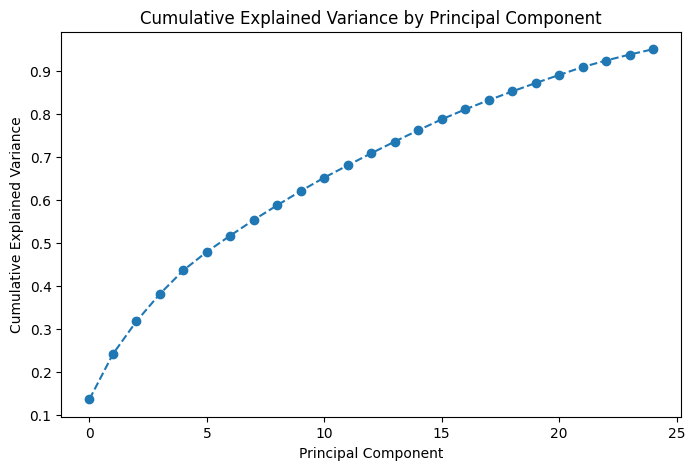

In [10]:
# how many of varicance is explained by each component
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)
n_components = len(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(n_components), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Component')
plt.show()


The first two principal components explain only about 25% of the total variance, so the 2D PCA view is not very informative for separation. This suggests PCA is not revealing a strong low-dimensional clustering structure in this feature set.

In [11]:
loop_kmeans_eucleadean = KMeansTrainingLoop(X_scaled, range(2, 11))
loop_kmeans_eucleadean.train()
str(loop_kmeans_eucleadean)

'KMeansTrainingLoop(best_k=3, best_silhouette=0.4860, best_kmeans=KMeans(n_clusters=3, random_state=42))'

## Plot inertia and silhouette scores

### References

* [ISLR2, Ch12_Unsupervised_Learning.pdf](https://hastie.su.domains/ISLR2/Slides/Ch12_Unsupervised_Learning.pdf)

* [scikit-learn.org, silhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

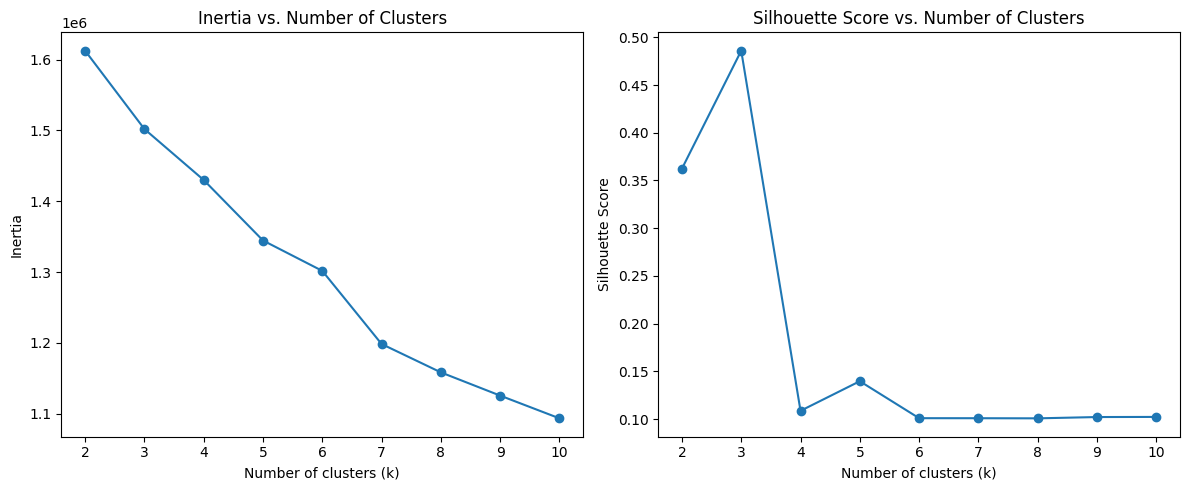

In [12]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loop_kmeans_eucleadean.k_values, loop_kmeans_eucleadean.inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Inertia vs. Number of Clusters")

plt.subplot(1, 2, 2)
plt.plot(loop_kmeans_eucleadean.k_values, loop_kmeans_eucleadean.silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.tight_layout()
plt.show()


Cosine-oriented K-Means: normalize vectors to unit length first.
K-Means itself is Euclidean, but on unit vectors Euclidean distance aligns with cosine similarity ranking.



In [13]:
loop_kmeans_cosine = KMeansTrainingLoop(X_normalized, range(2, 11))
loop_kmeans_cosine.train(eval_metric='cosine')
str(loop_kmeans_cosine)

'KMeansTrainingLoop(best_k=5, best_silhouette=0.1610, best_kmeans=KMeans(n_clusters=5, random_state=42))'

## Cosine KMeans baseline (not selected)

This experiment used unit-normalized features with KMeans and cosine silhouette scoring.
Observed silhouette performance was substantially weaker than the Euclidean KMeans baseline on standardized features.

Euclidean similarity on scaled data:

KMeansTrainingLoop(best_k=3, best_silhouette=**0.4860**, best_kmeans=KMeans(n_clusters=3, random_state=42))



Cosine similarity on normalized data:

KMeansTrainingLoop(best_k=5, best_silhouette=**0.1610**, best_kmeans=KMeans(n_clusters=5, random_state=42))


Given current results, this path is retained for reference only and excluded from downstream segmentation and profiling. For this project, **DBSCAN** remains the primary method because the objective is to identify atypical/noise behavior, not only maximize centroid-based partition quality.

### References

* MacQueen, J. (1967), "Some methods for classification and analysis of multivariate observations"

## DBSCAN Baseline: Why a Large Noise Count Can Happen

DBSCAN marks a point as noise (`-1`) when it has fewer than `min_samples` neighbors within radius `eps`.  
In high-dimensional feature spaces, pairwise distances tend to concentrate, so a small `eps` can leave most points without enough neighbors. This often leads to many (or nearly all) points being labeled as noise.

For this reason, DBSCAN is highly sensitive to `eps` and `min_samples`, and these parameters should be tuned (for example, with a k-distance plot) rather than fixed arbitrarily.

### References

- scikit-learn User Guide: DBSCAN and parameter sensitivity  
  https://scikit-learn.org/stable/modules/clustering.html#dbscan
- Ester, M., Kriegel, H.-P., Sander, J., Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*.
- Schubert, E., Sander, J., Ester, M., Kriegel, H.-P., Xu, X. (2017). *DBSCAN Revisited, Revisited: Why and How You Should (Still) Use DBSCAN*.

In [14]:
dbscan_euclidean_evaluator = DBSCANEvaluation(X_scaled)
dbscan_euclidean_evaluator.evaluate()
dbscan_euclidean_evaluator

DBSCAN Evaluation:
  Epsilon: 6.6332495807108
  Min Samples: 5
  Metric: euclidean
  Number of clusters: 13
  Number of noise points: 89
  Silhouette score: 0.48309429984839947

## Why Noise-Point Counting Matters

In density-based clustering, the number of noise points is not a side metric; it is a key diagnostic for whether DBSCAN is operating at a useful density threshold.

A very high noise count can indicate overly strict parameters, while a very low count can indicate an overly permissive neighborhood definition. Tracking this value helps us tune `eps` and `min_samples` with purpose.

For this project, these noise points are especially important: they represent customers whose purchasing behavior does not conform to dense, common patterns. Identifying and characterizing these atypical customers is a core objective of the research.

## Find eps for cosine similarity

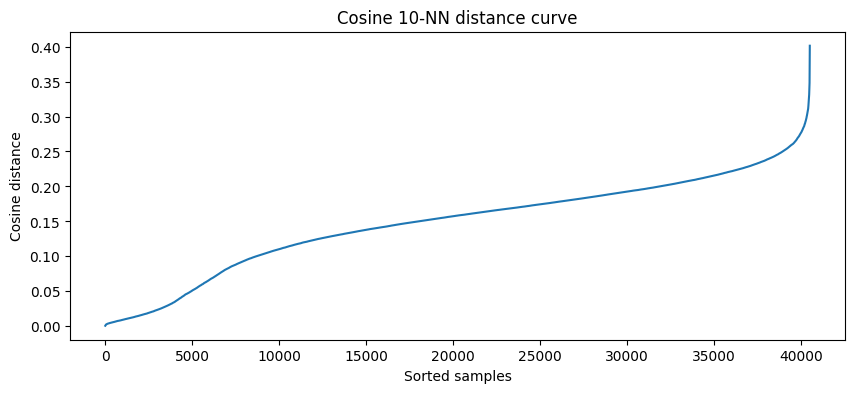

Initial eps guess: 0.2433


In [15]:
min_samples = 10

nn = NearestNeighbors(n_neighbors=min_samples, metric="cosine")
nn.fit(X_normalized)
distances, _ = nn.kneighbors(X_normalized)

kdist = np.sort(distances[:, -1])  # distance to k-th neighbor

# plot knee
plt.figure(figsize=(10, 4))
plt.plot(kdist)
plt.title(f"Cosine {min_samples}-NN distance curve")
plt.xlabel("Sorted samples")
plt.ylabel("Cosine distance")
plt.show()

# 4) starting eps guess: high quantile if knee is hard to see
eps_cosine = float(np.quantile(kdist, 0.95))
print(f"Initial eps guess: {eps_cosine:.4f}")

## Evaluate DBSCAN with cosine distance and normalized data

In [16]:
dbscan_cosine_evaluator = DBSCANEvaluation(X_normalized, eps=eps_cosine, min_samples=5, metric="cosine")
dbscan_cosine_evaluator.evaluate()
dbscan_cosine_evaluator

DBSCAN Evaluation:
  Epsilon: 0.24330133203745224
  Min Samples: 5
  Metric: cosine
  Number of clusters: 3
  Number of noise points: 64
  Silhouette score: -0.05489857153283868

## DBSCAN With Cosine Similarity: Current Status

DBSCAN with cosine distance produced a slightly negative silhouette **(−0.055)**, indicating weak geometric separation under this metric. However, because this study prioritizes identification of atypical customers, model selection is based primarily on noise-point relevance and parameter stability, with silhouette used as a secondary diagnostic.

Next, we will evaluate the stability and robustness of 2 DBSCAN models: euclidean and cosing similarity.

### Validation checks

- Small changes in `eps` and `min_samples` should yield similar results.
- Obtained clusters should be interpretable.
- The customers outside any cluster should be truly "out of line," not artifacts of data quality issues.

If these checks are satisfied, no additional clustering algorithms will be evaluated, because they are unlikely to move us closer to the research question.

In [17]:
estimator = DBSCANMinSamplesEstimator(
    eps=6.633, 
    min_samples_range=list(range(5, 51)), 
    metric="euclidean", 
    verbose=False
)

# if loading results failed, estimate min_samples
if estimator.load_results(project_root):
    print("Loaded results from file.\n")    
else:
    print("Estimating min_samples for DBSCAN with euclidean metric...")
    estimator.estimate(X_scaled)
    # persist results of the scan for later use
    estimator.save_results(project_root)

print(estimator)

Loaded results from file.

DBSCANMinSamplesEstimator(eps=6.633, min_samples_range=5 .. 50, metric=euclidean)
  Silhouette score min to max: 0.48309429984839947 to 0.505914583507099
  Number of clusters min to max: 5 to 13
  Number of noise points min to max: 89 to 255


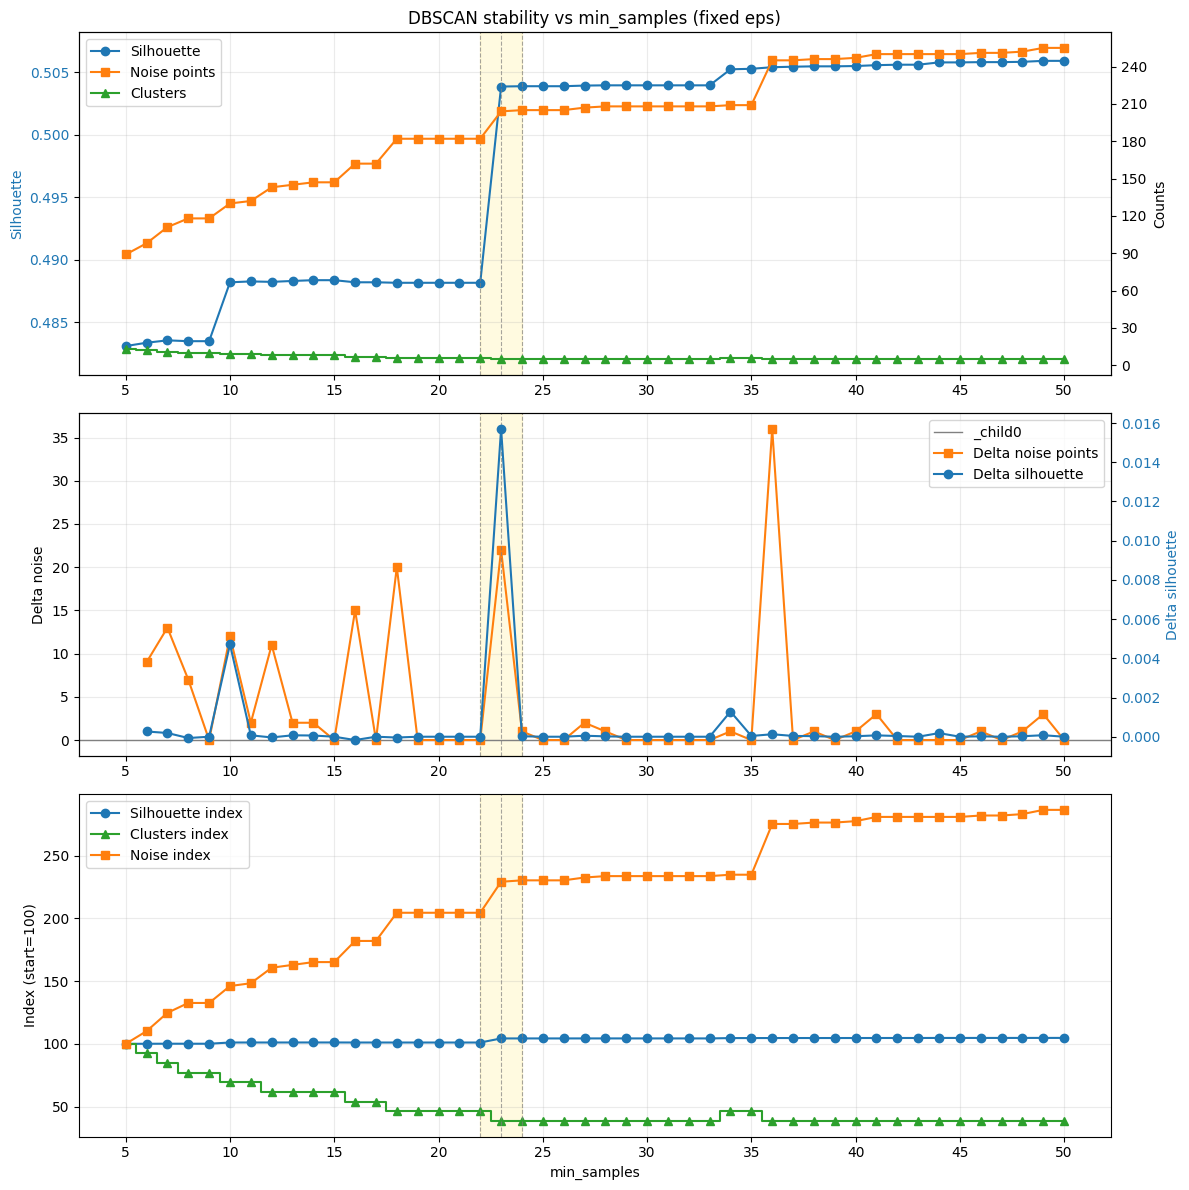

In [34]:
ms = np.array(estimator.min_samples_)
sil = np.array(estimator.silhouette_avg_, dtype=float)
clu = np.array(estimator.num_clusters_, dtype=float)
noi = np.array(estimator.num_noise_points_, dtype=float)

# First differences
d_sil = np.diff(sil)
d_noi = np.diff(noi)
ms_diff = ms[1:]

# Normalize to index=100 at first point
sil_idx = 100 * sil / sil[0]
clu_idx = 100 * clu / clu[0]
noi_idx = 100 * noi / noi[0]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Panel 1: levels
ax1 = axes[0]
ax1.plot(ms, sil, marker="o", color="#1f77b4", label="Silhouette")
ax1.set_ylabel("Silhouette", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(alpha=0.25)

ax1b = ax1.twinx()
ax1b.plot(ms, noi, **PLOT_STYLES['noise'], label="Noise points")
ax1b.plot(ms, clu, **PLOT_STYLES['clusters'], drawstyle="steps-mid", label="Clusters")
ax1b.set_ylabel("Counts")
ax1b.yaxis.set_major_locator(MaxNLocator(integer=True))

lines = ax1.get_lines() + ax1b.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")
ax1.set_title("DBSCAN stability vs min_samples (fixed eps)")

# Optional zoom: makes local silhouette plateau easier to inspect
sil_pad = max(0.001, 0.1 * (sil.max() - sil.min()))
ax1.set_ylim(sil.min() - sil_pad, sil.max() + sil_pad)

# Panel 2: first differences
ax2 = axes[1]
ax2.axhline(0, color="gray", linewidth=1)
ax2.plot(ms_diff, d_noi, **PLOT_STYLES['noise'], label="Delta noise points")
ax2.set_ylabel("Delta noise")
ax2.grid(alpha=0.25)

ax2b = ax2.twinx()
ax2b.plot(ms_diff, d_sil, marker="o", color="#1f77b4", label="Delta silhouette")
ax2b.set_ylabel("Delta silhouette", color="#1f77b4")
ax2b.tick_params(axis="y", labelcolor="#1f77b4")

lines2 = ax2.get_lines() + ax2b.get_lines()
labels2 = [l.get_label() for l in lines2]
ax2.legend(lines2, labels2, loc="best")

# Panel 3: normalized trends
ax3 = axes[2]
ax3.plot(ms, sil_idx, **PLOT_STYLES['silhouette'], label="Silhouette index")
ax3.plot(ms, clu_idx, **PLOT_STYLES['clusters'], drawstyle="steps-mid", label="Clusters index")
ax3.plot(ms, noi_idx, **PLOT_STYLES['noise'], label="Noise index")
ax3.set_xlabel("min_samples")
ax3.set_ylabel("Index (start=100)")
ax3.grid(alpha=0.25)
ax3.legend(loc="best")

# Readability improvements for all panels
candidate_min, candidate_max = 22, 24
for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.axvspan(candidate_min, candidate_max, color="gold", alpha=0.12)
    for x in [22, 23, 24]:
        ax.axvline(x, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

## Explanation of the "Index (start = 100)" Plot

This panel shows **relative change** for each metric as `min_samples` increases, not absolute values.

For each metric, we compute:
$$
\text{Index}_t = 100 \times \frac{\text{Metric}_t}{\text{Metric}_{\text{first}}}
$$

Interpretation guide:
- `100` means the metric is unchanged from the first tested `min_samples` value.
- `110` means the metric is 10% higher than the starting point.
- `90` means the metric is 10% lower than the starting point.

Why this panel is useful:
- It removes scale mismatch (for example, noise-point counts vs silhouette values).
- It makes trend direction and relative magnitude directly comparable on one axis.

How to read the three lines in this experiment:
- **Silhouette index**: slightly increases above `100` in the current sweep, indicating a modest improvement in separation as `min_samples` increases.
- **Clusters index**: decreases (step-like), indicating fewer clusters as the density requirement becomes stricter.
- **Noise index**: increases above `100`, indicating more samples are labeled as noise.

Overall, this plot supports expected DBSCAN behavior under fixed `eps`: increasing `min_samples` makes the model more conservative while shifting the balance toward fewer clusters and more noise points.

## Reflection on Results

### Experiment setup and parameter meaning

`min_samples` is the minimum number of samples in a local neighborhood (including the point itself) for a point to be considered a core point in DBSCAN. Increasing `min_samples` makes the density requirement stricter, which typically leads to denser clusters and more points labeled as noise.

Reference: [scikit-learn DBSCAN documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

In this experiment, `eps` was kept fixed and `min_samples` was swept from 5 to 29. The baseline started at the default value `min_samples = 5`. As `min_samples` increased, the number of clusters decreased and the number of noise points increased gradually. In the current sweep, the silhouette score also increased slightly (from approximately 0.483 to 0.504), indicating a modest improvement in separation under stricter density constraints.

### Interpretation in the context of this research

Silhouette is treated as a supporting metric, not the sole decision criterion. For this project, the most important outcomes are:
- Whether the resulting number of clusters is interpretable.
- Whether the number of noise points is meaningful for identifying atypical customers.

From an empirical perspective, this sweep is promising. At lower `min_samples`, cluster count is relatively high and harder to interpret. At higher `min_samples`, the cluster structure becomes more compact and easier to reason about, while the noise-point count remains substantial enough to support anomaly-focused analysis.

## Run min_samples estimation for DBSCAN with cosine similarity

In [20]:
estimator_cosine = DBSCANMinSamplesEstimator(
    eps=eps_cosine,
    min_samples_range=list(range(5, 31)), 
    metric="cosine", 
    verbose=False
)

if estimator_cosine.load_results(project_root):
    print("Loaded results from file.\n")
else:
    print("Estimating min_samples for DBSCAN with cosine metric...")
    estimator_cosine.estimate(X_normalized)
    # persist results of the scan for later use
    estimator_cosine.save_results(project_root)

print(estimator_cosine)

Loaded results from file.

DBSCANMinSamplesEstimator(eps=0.24330133203745224, min_samples_range=5 .. 30, metric=cosine)
  Silhouette score min to max: -0.16573066536399678 to 0.019988392248097658
  Number of clusters min to max: 2 to 5
  Number of noise points min to max: 64 to 1293


## Simple plot of scan for min_samples with cosine similarity

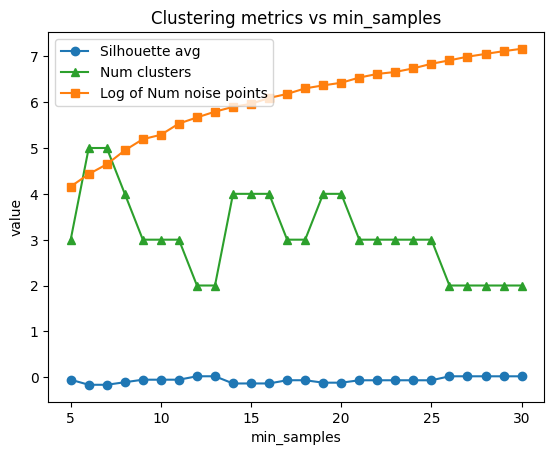

In [21]:
min_samples  = np.array(estimator_cosine.min_samples_, dtype=int)
silhouette   = np.array(estimator_cosine.silhouette_avg_, dtype=float)
num_clusters = np.array(estimator_cosine.num_clusters_, dtype=float)
num_noise    = np.log(estimator_cosine.num_noise_points_)

plt.figure()
plt.plot(min_samples, silhouette, label="Silhouette avg", **PLOT_STYLES['silhouette'])
plt.plot(min_samples, num_clusters, label="Num clusters", **PLOT_STYLES['clusters'])
plt.plot(min_samples, num_noise,    label="Log of Num noise points", **PLOT_STYLES['noise'])

plt.xlabel("min_samples")
plt.ylabel("value")
plt.title("Clustering metrics vs min_samples")
plt.legend()
plt.show()


## Reflection on scan results for DBSCAN with cosine similarity

I will not continue with this model — it seems a poor fit for my research. The silhouette score remains very low, the number of clusters fluctuates between 2 and 5, and only the noise points show a clear tendency to grow — but this alone does not look likely to produce a feasible analysis.

## Evaluate misc. epsilon values while holding 'min_samples' fixed

In [22]:
estimator23 = DBSCANEpsEstimator(
    eps_range=np.arange(5.0, 10.0, 0.5).tolist(),
    min_samples=23,    
    metric="euclidean",
    verbose=False
)

if estimator23.load_results(project_root):
    print("Loaded results from file.\n")
else:
    print("Estimating eps for DBSCAN with euclidean metric...")
    estimator23.estimate(X_scaled)
    # persist results of the scan for later use
    estimator23.persist_results(project_root)

print(estimator23)

Loaded results from file.

DBSCANEpsEstimator(eps_range=5.0 .. 9.5, min_samples=23, metric=euclidean)
  Silhouette score min to max: 0.3285757660097867 to 0.35867410032916136
  Number of clusters min to max: 2 to 10
  Number of noise points min to max: 128 to 386


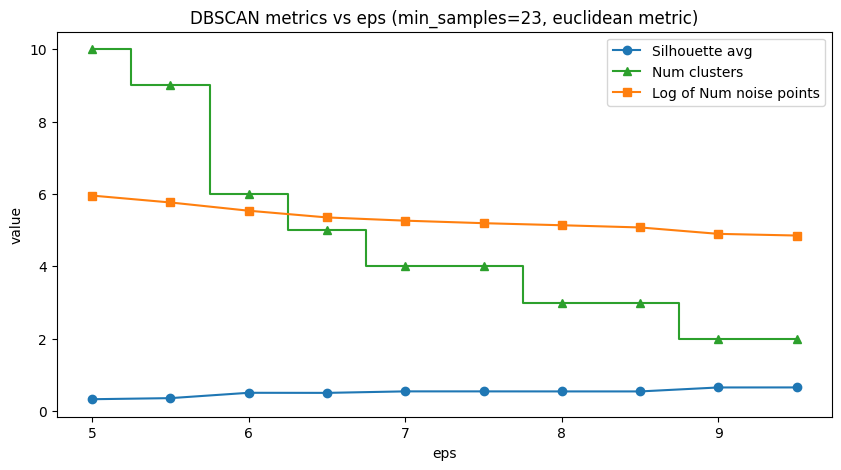

In [ ]:
# plot results for DBSCAN eps estimation
plot_eps_metrics(estimator23)

## Reflection on DBSCAN Sweep with Fixed `min_samples = 23`

The trend is clear: in the current sweep, as `eps` increases, the number of clusters decreases (from 10 to 2), the number of noise points also decreases, and the silhouette score improves modestly.

This behavior is consistent with the scikit-learn guidance: *"Choosing `eps` is critical; if it is too small, most data will be labeled as noise, and if it is too large, clusters can merge into one."*
Source: [scikit-learn DBSCAN documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

From a research perspective, this sweep helps identify practical parameter boundaries. There is room to tune the model for better interpretability. Unless cosine-distance sweeps show clearly superior behavior (which currently seems unlikely), the Euclidean configuration remains the leading candidate.

In [24]:
esti0 = DBSCANEpsEstimator(
    eps_range=np.arange(eps_cosine - 0.15, eps_cosine + 1.0, 0.1).tolist(),
    min_samples=22,
    metric="cosine",
    verbose=True
)

if esti0.load_results(project_root):
    print("Loaded results from file.\n")
else:
    print("Estimating eps for DBSCAN with cosine metric...")
    esti0.estimate(X_normalized)
    esti0.persist_results(project_root)

print(esti0)

Loaded results from file.

DBSCANEpsEstimator(eps_range=0.09330133203745225 .. 1.1933013320374524, min_samples=22, metric=cosine)
  Silhouette score min to max: 0.4330119860535042 to -0.2126099601251788
  Number of clusters min to max: 1 to 51
  Number of noise points min to max: 0 to 33304


c:\Users\SimonShtock\source\unusual-customer-purchasing\src\plotting.py:28: RuntimeWarning: divide by zero encountered in log
  np.log(estimator.num_noise_points_),


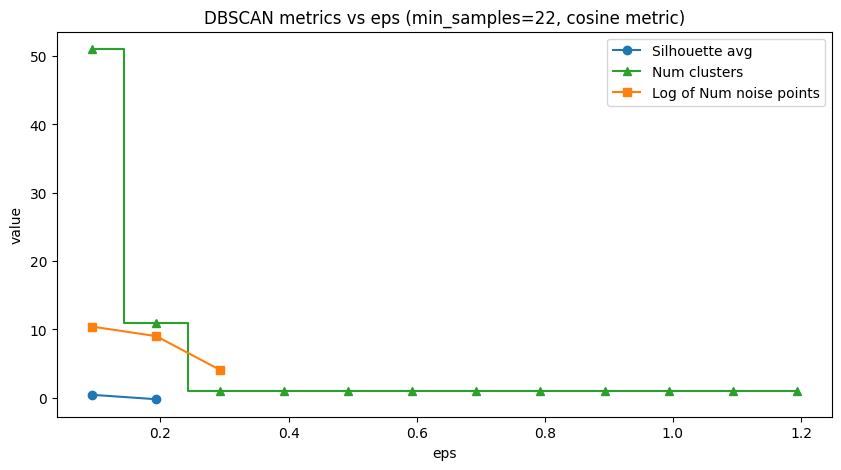

In [ ]:
# plot results for DBSCAN eps estimation
plot_eps_metrics(esti0)

## Reflection on Cosine-Similarity Sweep

Based on the current sweep, this cosine-distance configuration appears to be a weak fit for the research objective. The clustering structure is unstable and less interpretable than the Euclidean alternative, with no compensating improvement in separation quality.

Given these results, this branch will be discontinued and the analysis will proceed with the stronger Euclidean DBSCAN configuration.

## Final Fit

Goal: obtain interpretable segments (ideally 2 to 5 clusters) with meaningful noise points for anomaly-focused analysis.

### Locked model settings

`min_samples` was fixed at **23** because this value marks the start of a local stability region where silhouette and noise-point behavior remain stable, while cluster count stays interpretable.

`eps` was fixed at the value where the model yields 2 clusters, the highest silhouette score observed in the selected region, and an interpretable number of noise points.

In [26]:
dbscan23 = DBSCANEvaluation(X_scaled, eps=9.0, min_samples=23, metric="euclidean")
dbscan23.evaluate()
print(dbscan23)

DBSCAN Evaluation:
  Epsilon: 9.0
  Min Samples: 23
  Metric: euclidean
  Number of clusters: 2
  Number of noise points: 134
  Silhouette score: 0.6535948030803757



In [27]:
df_noise = df_features[dbscan23.labels_ == -1]
df_cluster0 = df_features[dbscan23.labels_ == 0]
df_cluster1 = df_features[dbscan23.labels_ == 1]
df_clusters = df_features[dbscan23.labels_ != -1]

print(f"Noise points: {len(df_noise)}")
print(f"Cluster 0 points: {len(df_cluster0)}")
print(f"Cluster 1 points: {len(df_cluster1)}")
print(f"Total clustered points: {len(df_clusters)}")

Noise points: 134
Cluster 0 points: 40221
Cluster 1 points: 150
Total clustered points: 40371


## Characterizing outliers via standardized mean differences (Cohen's d)

I will compare the outliers with the combined clusters (all data excluding outliers), using each column except the non-informative ones such as
'customer_id', 'invoice', and 'invoice_datetime'. For each remaining column I compute Cohen's d — the difference in means divided by the standard deviation —
so that differences are standardized and comparable across features regardless of their units.

Taking only the top-difference columns is not enough; the difference must be significant. In numbers, Cohen's d should be around 0.8 or greater in absolute
value (Cohen's conventional threshold for a "large" effect). Once I have several columns with a significant difference, I will be able to characterize the outliers.

The same approach can be used to find the difference between cluster 0 and cluster 1.

### References

**Standardized mean difference (Cohen's d)**
Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences*
(2nd ed.). Lawrence Erlbaum. — Effect size as mean difference in
standard-deviation units; conventional benchmarks d = 0.2 / 0.5 / 0.8
(small / medium / large). Glass's delta is the appropriate variant when the
two groups have unequal variances (standardize by the reference group's SD).

**Explaining outliers with a supervised surrogate model**
Li, Z., Zhu, Y., & van Leeuwen, M. (2023). A Survey on Explainable Anomaly
Detection. *ACM Transactions on Knowledge Discovery from Data*.
arXiv:2210.06959. — Decision-tree surrogates give interpretable, rule-based
explanations characterizing an outlier relative to the inlier region;
SHAP/LIME give feature-importance explanations with differing semantics.

In [28]:
def cohens_d_from_features(df1, df2):
    # assuming df1 and df2 are subsets of the features dataframe, with the same columns

    dict = {}

    for column in df1.columns:
        if column in ["Invoice", "customer_id", "invoice_datetime"]:
            continue

        col1 = df1[column]
        col2 = df2[column]
        n1, n2 = len(col1), len(col2)
        m1, m2 = col1.mean(), col2.mean()
        v1, v2 = col1.var(ddof=1), col2.var(ddof=1)
        pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
        cohens_d = (m1 - m2) / pooled_std if pooled_std > 0 else np.nan

        dict[column] = np.abs(cohens_d)

    cohens_d_df = pd.DataFrame.from_dict(dict, orient='index', columns=["cohens_d_abs"])
    cohens_d_df.sort_values(by="cohens_d_abs", ascending=False, inplace=True)

    return cohens_d_df



## Top 5 Features with Largest Differences Between Clusters and Outliers

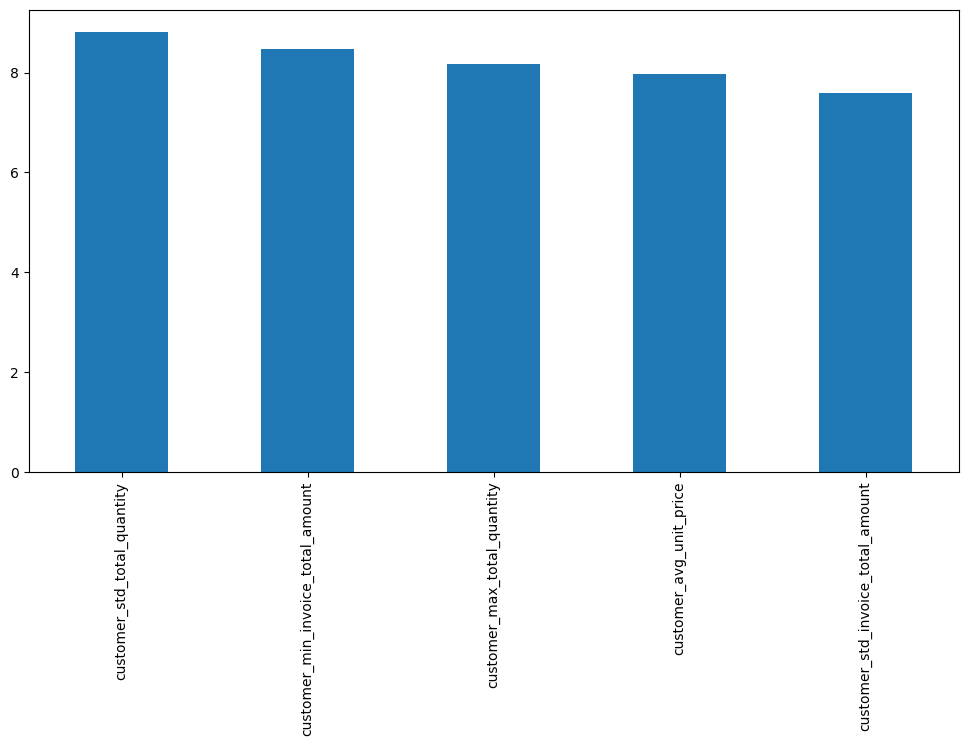

In [29]:
cohens_d_df = cohens_d_from_features(df_clusters, df_noise)

# we filter for features with a Cohen's d greater than 0.8, which is considered a large effect size
cohens_d_df = cohens_d_df[cohens_d_df["cohens_d_abs"] > 0.8]

# get top 5 features with the largest differences
cohens_d_df.head(5).plot(kind='bar', figsize=(12, 6), legend=False);

In [30]:
# get distinct customer ids from the noise points
distinct_customer_id = df_noise['customer_id'].unique()

# is any customer from df_noise also present in df_clusters?
common_customers = set(df_noise["customer_id"]).intersection(set(df_clusters["customer_id"]))

print(f"Distinct customer IDs in noise points: {len(distinct_customer_id)}")
print(f"Common customer IDs between noise points and clusters: {len(common_customers)}")

Distinct customer IDs in noise points: 41
Common customer IDs between noise points and clusters: 13


## Reflection on the Largest Differences Between Clusters and Outliers


Looking at the plot of the top 5 features with the largest Cohen's d, we immediately notice that the magnitudes of the differences are large, and that the differences are heavily driven by the **variability** of invoices: std. total quantity, std. total amount, and max total quantity. Another prominent feature is the min. invoice total for cancelled invoices (negative amount).

We can label these invoices as **high-volume, high-volatility wholesale transactions**.

From the number of distinct customers (41) behind the outlier invoices (134), we notice that outlier invoices concentrate in relatively few customers — on average several exceptional invoices per customer.
Furthermore, only 13 of these 41 customers also appear in the main clusters, meaning most outlier customers are distinct from the clustered ones: their purchasing behavior is exceptional across the board, not merely in a few isolated invoices.

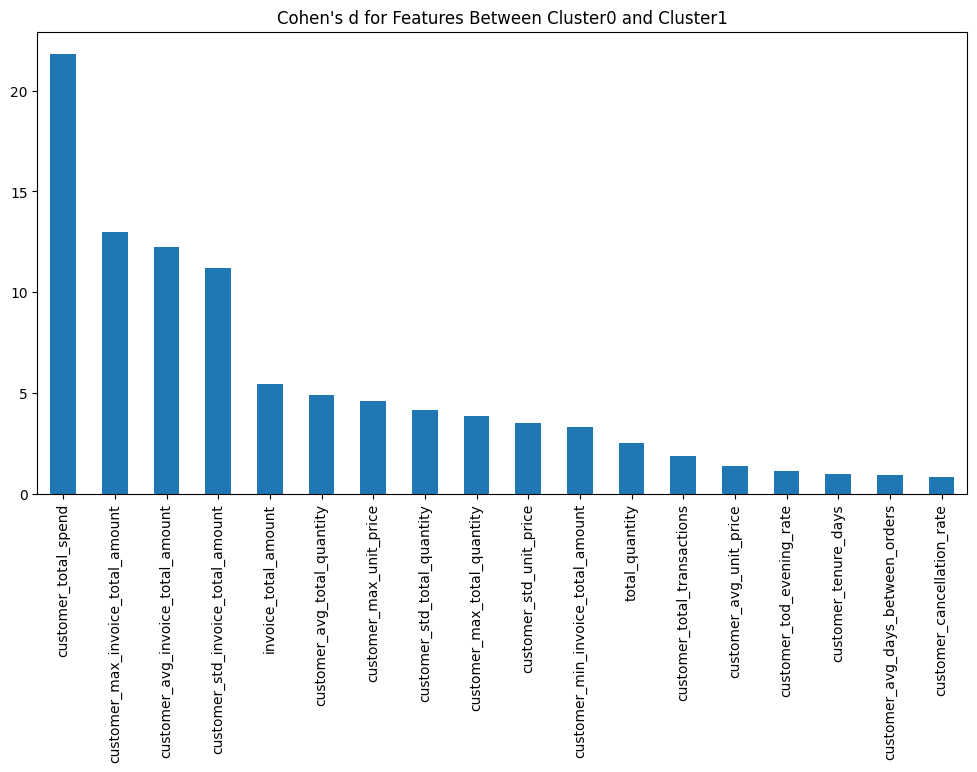

In [31]:
cohens_d_df2 = cohens_d_from_features(df_cluster0, df_cluster1)
cohens_d_df2 = cohens_d_df2[cohens_d_df2["cohens_d_abs"] > 0.8]

cohens_d_df2.plot(
    kind="bar",
    figsize=(12, 6),
    legend=False,
    title="Cohen's d for Features Between Cluster0 and Cluster1",
);

In [32]:
print(df_cluster0.customer_total_spend.mean())
print(df_cluster1.customer_total_spend.mean())

13158.053502473831
598215.2199999999


## Reflection on the Largest Differences Between Cluster 0 and Cluster 1

The driving characteristic distinguishing cluster 0 from cluster 1 is the amount spent: cluster 1 can be labeled as **high total spend**. The single leading feature, `customer_total_spend`, is about 20 standard deviations higher in cluster 1. The next most significant features are correlated with `customer_total_spend`: `max_invoice_amount`, `avg_invoice_amount`, and so on.

# Conclusions

DBSCAN flagged 134 invoices from 41 customers as outliers. These fall into two types: high-volume wholesale accounts, and high-value cancellation/adjustment records. 
The distinguishing features are: 
- `customer_std_total_quantity`
- `customer_min_invoice_total_amount`
- `customer_max_total_quantity`
- `customer_avg_unit_price`
- `customer_std_invoice_total_amount`

Notably, these customers mostly also does not have normal invoices in the main clusters — they are a separate population.

A 2-clusters separation, obtained from DBSCAN also was meanigful - see reflection above.